In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:
# Paths
PKL_PATH     = '/content/drive/MyDrive/trash_model/taco_preprocessed_balanced.pkl'
MODEL_SAVE   = '/content/drive/MyDrive/trash_model/resnet50_best.pth'
RESULTS_SAVE = '/content/drive/MyDrive/trash_model/resnet50.pkl'

# Training
BATCH_SIZE    = 32
EPOCHS        = 20
LEARNING_RATE = 0.001
PATIENCE      = 5

# Model
IMAGE_SIZE  = 224
NUM_CLASSES = 2
CLASS_NAMES = ['Recyclable', 'Non-Recyclable']

print('Configuration set.')
print(f'  Batch size    : {BATCH_SIZE}')
print(f'  Epochs        : {EPOCHS} (early stop patience={PATIENCE})')
print(f'  Learning rate : {LEARNING_RATE}')

Configuration set.
  Batch size    : 32
  Epochs        : 20 (early stop patience=5)
  Learning rate : 0.001


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pickle # Added import statement for pickle

with open(PKL_PATH, 'rb') as f:
    data = pickle.load(f)

X_train       = data['X_train']       # (1400, 224, 224, 3) float32
y_train       = data['y_train']       # (1400,) int64
X_val         = data['X_val']         # (300, 224, 224, 3) float32
y_val         = data['y_val']         # (300,) int64
X_test        = data['X_test']        # (300, 224, 224, 3) float32
y_test        = data['y_test']        # (300,) int64
class_weights = data['class_weights']

print('Dataset loaded.')
print(f'  Train : {X_train.shape}')
print(f'  Val   : {X_val.shape}')
print(f'  Test  : {X_test.shape}')
print(f'  Pixel range : [{X_train.min():.2f}, {X_train.max():.2f}]')
print(f'  Class weights : {class_weights}')

Mounted at /content/drive
Dataset loaded.
  Train : (1400, 224, 224, 3)
  Val   : (300, 224, 224, 3)
  Test  : (300, 224, 224, 3)
  Pixel range : [0.00, 1.00]
  Class weights : [1. 1.]


In [ ]:
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler # Added WeightedRandomSampler
from collections import Counter # Added Counter for print statement

class WasteDataset(Dataset):
    """
    Loads images from numpy arrays (H,W,3) normalized [0,1].
    Converts to PIL then applies transforms.
    """
    def __init__(self, images, labels, transform=None):
        self.images    = images
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img   = self.images[idx]
        label = int(self.labels[idx])
        img_pil = Image.fromarray((img * 255).astype(np.uint8))
        if self.transform:
            img = self.transform(img_pil)
        else:
            img = transforms.ToTensor()(img_pil)
        return img, label


# Transforms
# Training: extra augmentation on top of Phase 1 augmentation
# Val/Test: only normalize — no augmentation (fair evaluation)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Datasets
train_dataset = WasteDataset(X_train, y_train, transform=train_transform)
val_dataset   = WasteDataset(X_val,   y_val,   transform=val_test_transform)
test_dataset  = WasteDataset(X_test,  y_test,  transform=val_test_transform)

# WeightedRandomSampler — balanced batches during training
sample_weights = [class_weights[int(l)] for l in y_train]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=2, pin_memory=True)

print('DataLoaders ready.')
print(f'  Train batches : {len(train_loader)}')
print(f'  Val batches   : {len(val_loader)}')
print(f'  Test batches  : {len(test_loader)}')

imgs, lbls = next(iter(train_loader))
print(f'  Batch shape   : {imgs.shape}')   # (32, 3, 224, 224)
print(f'  Label dist    : {Counter(lbls.numpy().tolist())}')

DataLoaders ready.
  Train batches : 44
  Val batches   : 10
  Test batches  : 10
  Batch shape   : torch.Size([32, 3, 224, 224])
  Label dist    : Counter({1: 21, 0: 11})


In [ ]:
class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1      = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1        = nn.BatchNorm2d(out_channels)
        self.conv2      = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2        = nn.BatchNorm2d(out_channels)
        self.conv3      = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, bias=False)
        self.bn3        = nn.BatchNorm2d(out_channels * self.expansion)
        self.relu       = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        if self.downsample:
            identity = self.downsample(x)
        out += identity
        return self.relu(out)


class ResNet50(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.in_channels = 64
        self.conv1   = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1     = nn.BatchNorm2d(64)
        self.relu    = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1  = self._make_layer(64,  3)
        self.layer2  = self._make_layer(128, 4, stride=2)
        self.layer3  = self._make_layer(256, 6, stride=2)
        self.layer4  = self._make_layer(512, 3, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5)
        self.fc      = nn.Linear(512 * Bottleneck.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * Bottleneck.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * Bottleneck.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * Bottleneck.expansion)
            )
        layers = [Bottleneck(self.in_channels, out_channels, stride, downsample)]
        self.in_channels = out_channels * Bottleneck.expansion
        for _ in range(1, blocks):
            layers.append(Bottleneck(self.in_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x)


model = ResNet50(num_classes=2).to(device)
print('ResNet50 built from scratch!')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

ResNet50 built from scratch!
Total parameters: 23,512,130


In [ ]:
# Use loaded class weights
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

EPOCHS = 30  # increased from 15
train_losses, val_losses, val_accs = [], [], []
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}'):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            val_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct / total
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)

    print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_resnet50.pth')
        print(f'  ✓ Best model saved')

    scheduler.step()

print(f'\nTraining complete! Best val accuracy: {best_val_acc:.4f}')

Epoch 1/30: 100%|██████████| 44/44 [00:15<00:00,  2.86it/s]


Epoch 1/30 | Train Loss: 0.8659 | Val Loss: 0.7161 | Val Acc: 0.5233
  ✓ Best model saved


Epoch 2/30: 100%|██████████| 44/44 [00:14<00:00,  3.06it/s]


Epoch 2/30 | Train Loss: 0.7493 | Val Loss: 2.4206 | Val Acc: 0.5300
  ✓ Best model saved


Epoch 3/30: 100%|██████████| 44/44 [00:14<00:00,  3.01it/s]


...

Epoch 28/30 | Train Loss: 0.3736 | Val Loss: 0.4255 | Val Acc: 0.7867


Epoch 29/30: 100%|██████████| 44/44 [00:16<00:00,  2.62it/s]


Epoch 29/30 | Train Loss: 0.4095 | Val Loss: 0.5949 | Val Acc: 0.7567


Epoch 30/30: 100%|██████████| 44/44 [00:16<00:00,  2.62it/s]


Epoch 30/30 | Train Loss: 0.3734 | Val Loss: 0.4006 | Val Acc: 0.8433

Training complete! Best val accuracy: 0.8600


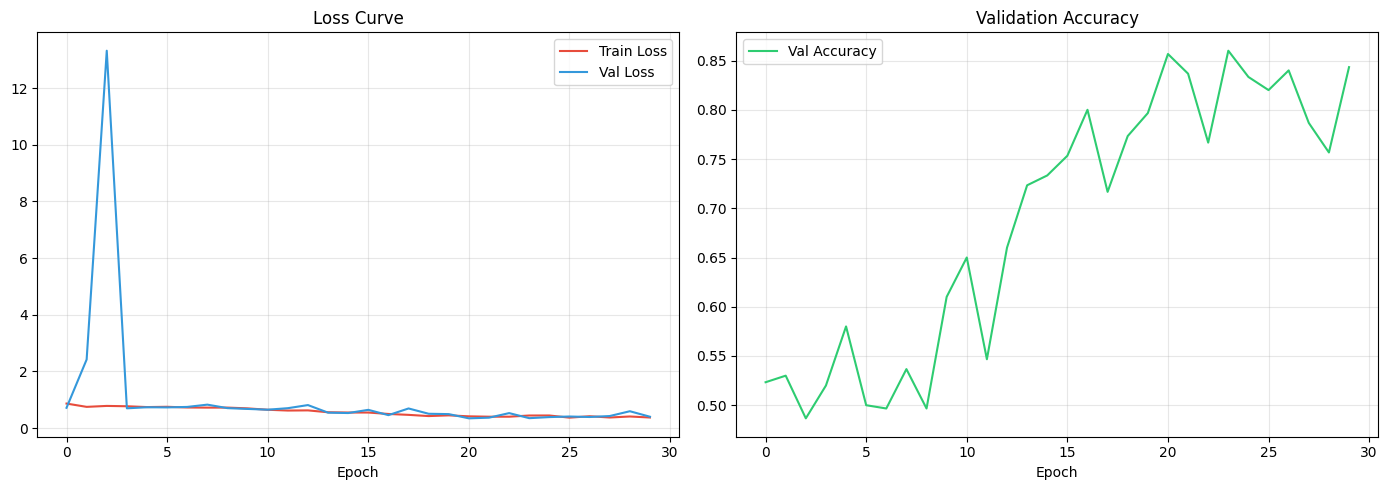

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss', color='#e74c3c')
ax1.plot(val_losses,   label='Val Loss',   color='#3498db')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(val_accs, label='Val Accuracy', color='#2ecc71')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

CLASSIFICATION REPORT
                precision    recall  f1-score   support

    Recyclable       0.93      0.74      0.82       150
Non-Recyclable       0.78      0.94      0.85       150

      accuracy                           0.84       300
     macro avg       0.85      0.84      0.84       300
  weighted avg       0.85      0.84      0.84       300

F1 — Recyclable:     0.8222
F1 — Non-Recyclable: 0.8545
F1 — Macro avg:      0.8384
F1 — Weighted avg:   0.8384


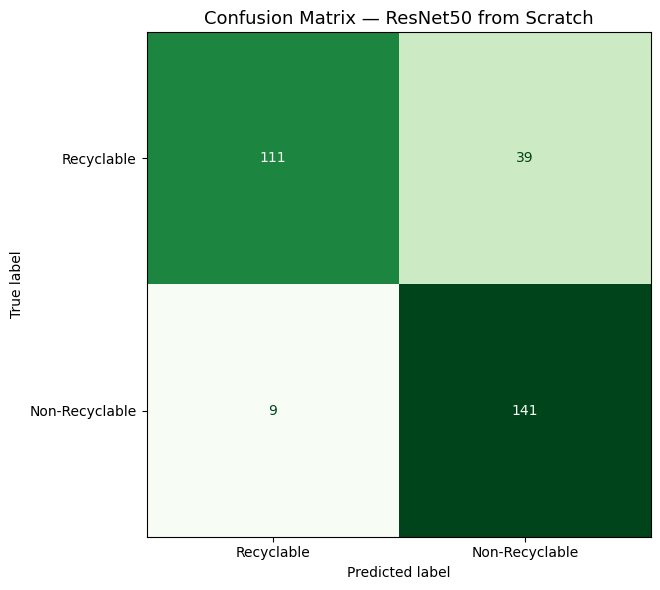

In [ ]:
model.load_state_dict(torch.load('best_resnet50.pth'))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        _, predicted = torch.max(model(imgs), 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print('=' * 50)
print('CLASSIFICATION REPORT')
print('=' * 50)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

f1_per_class = f1_score(all_labels, all_preds, average=None)
f1_macro     = f1_score(all_labels, all_preds, average='macro')
f1_weighted  = f1_score(all_labels, all_preds, average='weighted')

print(f'F1 — Recyclable:     {f1_per_class[0]:.4f}')
print(f'F1 — Non-Recyclable: {f1_per_class[1]:.4f}')
print(f'F1 — Macro avg:      {f1_macro:.4f}')
print(f'F1 — Weighted avg:   {f1_weighted:.4f}')

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Confusion Matrix — ResNet50 from Scratch', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
from google.colab import files
torch.save({'model_state_dict': model.state_dict(), 'class_names': CLASS_NAMES}, 'trash_classifier.pth')
files.download('trash_classifier.pth')
files.download('confusion_matrix.png')
files.download('training_curves.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>